# 07E — Error and Result Analysis for Conditional Sampling

This notebook analyses the merged conditional sampling dataset.

It is designed for the dataset structure:

- `simulation_id`
- `patient_id`
- `variation_id`
- `simulation_status`
- `error_message`
- patient target variables
- tunable coefficients
- real Simulink outputs

There is no explicit `chunk_id` column, so this notebook reconstructs it from `simulation_id`:

```python
chunk_id = ((simulation_id - 1) // 50) + 1
```

The main goal is to understand why failures appear grouped/sequential.


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# ============================================================
# CONFIG
# ============================================================

CAMPAIGN_NAME = "conditional_sampling_100_patients_100_variations_v1"
EXPECTED_ROWS = 10_000
ROWS_PER_CHUNK = 50
VARIATIONS_PER_PATIENT = 100

ROOT = Path.cwd()

# If running from 07_Conditional_Sampling_Strategy, move to project root
if ROOT.name == "07_Conditional_Sampling_Strategy":
    ROOT = ROOT.parent

RESULTS_DIR = (
    ROOT
    / "01_Data"
    / "Conditional_Sampling"
    / "simulation_results"
    / CAMPAIGN_NAME
)

DATASET_PATH = RESULTS_DIR / f"{CAMPAIGN_NAME}_FULL_DATASET.csv"
ANALYSIS_DIR = RESULTS_DIR / "analysis_07E"

ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("DATASET_PATH:", DATASET_PATH)
print("ANALYSIS_DIR:", ANALYSIS_DIR)

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset not found:\n{DATASET_PATH}")

ROOT: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project
DATASET_PATH: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\conditional_sampling_100_patients_100_variations_v1_FULL_DATASET.csv
ANALYSIS_DIR: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E


In [2]:
# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(DATASET_PATH)

print("Loaded dataset shape:", df.shape)
display(df.head())

Loaded dataset shape: (10000, 55)


,simulation_id,patient_id,variation_id,campaign_name,sampling_method,random_seed,EDVLV,ESVLV,LVSV,LVEF,EDVRV,ESVRV,RVSV,RVEF,hr,COLV,SVR,PVR,CVP,LAP,MAP,SAP,DAP,mPAP,sPAP,dPAP,weight,Rsysven,mcfp,graft_length,BSA,k_Vtot,k_Vsys,k_Vusv_sys,k_Vusv_sys_ven,k_Vusv_pulm_ven,k_Ctot,k_Csys,k_Rsysven,k_Rpulmart,k_ESP_LV,k_ESP_RV,LAP_real,RAP_real,SAP_real,DAP_real,sPAP_real,dPAP_real,EDV_LV_real,ESV_LV_real,EDV_RV_real,ESV_RV_real,CO_real,simulation_status,error_message
0,1,1,1,conditional_sampling_100_patients_100_variatio...,conditional_patient_sampling_plus_lhs_tunables,42,182.585699,157.38683,25.198868,13.801118,56.12997,30.931102,25.198868,44.893785,102,2570.284572,1.198952,0.692958,15.230286,26.024555,66.591067,88.524436,55.624382,55.70956,62.70956,48.70956,15.253845,0.314536,28.704408,0.186144,7.160298,61.860941,0.824416,0.866572,0.903116,0.918053,2.263535,0.859027,0.069085,0.648889,0.949103,1.028859,22.907717,15.033145,82.285484,55.694397,61.172193,44.483402,181.541071,154.048213,56.341245,28.998900,2.724620,success,NaN
1,2,1,2,conditional_sampling_100_patients_100_variatio...,conditional_patient_sampling_plus_lhs_tunables,42,182.585699,157.38683,25.198868,13.801118,56.12997,30.931102,25.198868,44.893785,102,2570.284572,1.198952,0.692958,15.230286,26.024555,66.591067,88.524436,55.624382,55.70956,62.70956,48.70956,15.253845,0.314536,28.704408,0.186144,7.160298,83.393249,0.903241,0.767588,0.929641,0.832593,2.378265,0.904596,0.062458,0.608202,1.024249,0.971820,18.071850,15.444618,85.370271,57.503690,57.340694,40.468176,176.608136,148.136314,56.869904,28.816355,2.823068,success,NaN
2,3,1,3,conditional_sampling_100_patients_100_variatio...,conditional_patient_sampling_plus_lhs_tunables,42,182.585699,157.38683,25.198868,13.801118,56.12997,30.931102,25.198868,44.893785,102,2570.284572,1.198952,0.692958,15.230286,26.024555,66.591067,88.524436,55.624382,55.70956,62.70956,48.70956,15.253845,0.314536,28.704408,0.186144,7.160298,66.625166,0.777674,0.787824,0.928008,0.888127,2.544958,0.854481,0.055228,0.533775,0.921389,0.950050,22.110526,15.194349,80.041703,54.347128,59.134811,43.067215,180.841803,154.230318,56.695777,30.263820,2.620437,success,NaN
3,4,1,4,conditional_sampling_100_patients_100_variatio...,conditional_patient_sampling_plus_lhs_tunables,42,182.585699,157.38683,25.198868,13.801118,56.12997,30.931102,25.198868,44.893785,102,2570.284572,1.198952,0.692958,15.230286,26.024555,66.591067,88.524436,55.624382,55.70956,62.70956,48.70956,15.253845,0.314536,28.704408,0.186144,7.160298,69.896788,0.862832,0.815217,0.987093,0.898846,2.137747,0.813468,0.064522,0.718078,0.967029,0.996113,21.702331,15.456106,83.176579,56.360027,60.004603,43.433931,180.478823,153.008526,56.843103,29.505275,2.742038,success,NaN
4,5,1,5,conditional_sampling_100_patients_100_variatio...,conditional_patient_sampling_plus_lhs_tunables,42,182.585699,157.38683,25.198868,13.801118,56.12997,30.931102,25.198868,44.893785,102,2570.284572,1.198952,0.692958,15.230286,26.024555,66.591067,88.524436,55.624382,55.70956,62.70956,48.70956,15.253845,0.314536,28.704408,0.186144,7.160298,66.349479,0.764524,0.760250,0.922636,0.923261,2.523486,0.807167,0.066768,0.787093,0.992213,1.027399,21.525575,15.520901,84.987306,57.444121,60.751431,43.638828,180.580961,152.262871,56.868855,28.909142,2.812136,success,NaN


In [3]:
# ============================================================
# ADD DERIVED INDEX COLUMNS
# ============================================================

if "simulation_status" not in df.columns:
    raise KeyError("Expected a column called simulation_status.")

if "simulation_id" not in df.columns:
    raise KeyError("Expected a column called simulation_id.")

df["simulation_id"] = pd.to_numeric(df["simulation_id"], errors="coerce").astype("Int64")

# Derived chunk from simulation_id. This assumes chunk 1 contains simulation IDs 1-50.
df["derived_chunk_id"] = ((df["simulation_id"].astype(int) - 1) // ROWS_PER_CHUNK) + 1
df["position_in_chunk"] = ((df["simulation_id"].astype(int) - 1) % ROWS_PER_CHUNK) + 1

# If patient_id / variation_id exist, force numeric.
for col in ["patient_id", "variation_id"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

# Fallback derivation if needed.
if "patient_id" not in df.columns:
    df["derived_patient_id"] = ((df["simulation_id"].astype(int) - 1) // VARIATIONS_PER_PATIENT) + 1
else:
    df["derived_patient_id"] = df["patient_id"].astype(int)

if "variation_id" not in df.columns:
    df["derived_variation_id"] = ((df["simulation_id"].astype(int) - 1) % VARIATIONS_PER_PATIENT) + 1
else:
    df["derived_variation_id"] = df["variation_id"].astype(int)

df["is_failed"] = df["simulation_status"].astype(str).str.lower().eq("failed")
df["is_success"] = df["simulation_status"].astype(str).str.lower().eq("success")

print("Added columns:")
print(["derived_chunk_id", "position_in_chunk", "derived_patient_id", "derived_variation_id", "is_failed", "is_success"])

display(df[[
    "simulation_id",
    "patient_id" if "patient_id" in df.columns else "derived_patient_id",
    "variation_id" if "variation_id" in df.columns else "derived_variation_id",
    "derived_chunk_id",
    "position_in_chunk",
    "simulation_status",
    "error_message" if "error_message" in df.columns else "simulation_status"
]].head(10))

Added columns:
['derived_chunk_id', 'position_in_chunk', 'derived_patient_id', 'derived_variation_id', 'is_failed', 'is_success']


,simulation_id,patient_id,variation_id,derived_chunk_id,position_in_chunk,simulation_status,error_message
0,1,1,1,1,1,success,NaN
1,2,1,2,1,2,success,NaN
2,3,1,3,1,3,success,NaN
3,4,1,4,1,4,success,NaN
4,5,1,5,1,5,success,NaN
5,6,1,6,1,6,success,NaN
6,7,1,7,1,7,success,NaN
7,8,1,8,1,8,success,NaN
8,9,1,9,1,9,success,NaN
9,10,1,10,1,10,success,NaN


In [4]:
# ============================================================
# BASIC DATASET CHECKS
# ============================================================

print("=" * 80)
print("BASIC DATASET CHECKS")
print("=" * 80)

print(f"Rows found: {len(df):,}")
print(f"Expected rows: {EXPECTED_ROWS:,}")
print(f"Difference: {EXPECTED_ROWS - len(df):,}")

print("\nSimulation status counts:")
print(df["simulation_status"].value_counts(dropna=False))

print("\nSimulation ID checks:")
print("min:", df["simulation_id"].min())
print("max:", df["simulation_id"].max())
print("unique:", df["simulation_id"].nunique())
print("duplicates:", df["simulation_id"].duplicated().sum())

sim_ids = df["simulation_id"].dropna().astype(int)
lo, hi = sim_ids.min(), sim_ids.max()
missing_ids = sorted(set(range(lo, hi + 1)) - set(sim_ids))
print("missing simulation IDs between min/max:", len(missing_ids))
print("first missing IDs:", missing_ids[:50])

print("\nDerived chunk checks:")
chunk_counts = df["derived_chunk_id"].value_counts().sort_index()
print(chunk_counts.describe())
print("\nChunks with row count != 50:")
display(chunk_counts[chunk_counts != ROWS_PER_CHUNK])

basic_summary_path = ANALYSIS_DIR / "basic_status_counts.csv"
df["simulation_status"].value_counts(dropna=False).to_csv(basic_summary_path)
print("\nSaved:", basic_summary_path)

BASIC DATASET CHECKS
Rows found: 10,000
Expected rows: 10,000
Difference: 0

Simulation status counts:
simulation_status
success    9200
failed      800
Name: count, dtype: int64

Simulation ID checks:
min: 1
max: 10000
unique: 10000
duplicates: 0
missing simulation IDs between min/max: 0
first missing IDs: []

Derived chunk checks:
count    200.0
mean      50.0
std        0.0
min       50.0
25%       50.0
50%       50.0
75%       50.0
max       50.0
Name: count, dtype: float64

Chunks with row count != 50:


Series([], Name: count, dtype: int64)


Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\basic_status_counts.csv


,derived_chunk_id,n_rows,n_failed,n_success,first_simulation_id,last_simulation_id,first_patient,last_patient,failure_rate
0,1,50,0,50,1,50,1,1,0.0
1,2,50,0,50,51,100,1,1,0.0
2,3,50,0,50,101,150,2,2,0.0
3,4,50,0,50,151,200,2,2,0.0
4,5,50,0,50,201,250,3,3,0.0


,derived_chunk_id,n_rows,n_failed,n_success,first_simulation_id,last_simulation_id,first_patient,last_patient,failure_rate
47,48,50,50,0,2351,2400,24,24,1.0
46,47,50,50,0,2301,2350,24,24,1.0
45,46,50,50,0,2251,2300,23,23,1.0
44,45,50,50,0,2201,2250,23,23,1.0
16,17,50,50,0,801,850,9,9,1.0
17,18,50,50,0,851,900,9,9,1.0
97,98,50,50,0,4851,4900,49,49,1.0
96,97,50,50,0,4801,4850,49,49,1.0
196,197,50,50,0,9801,9850,99,99,1.0
197,198,50,50,0,9851,9900,99,99,1.0


Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\failure_rate_by_derived_chunk.csv


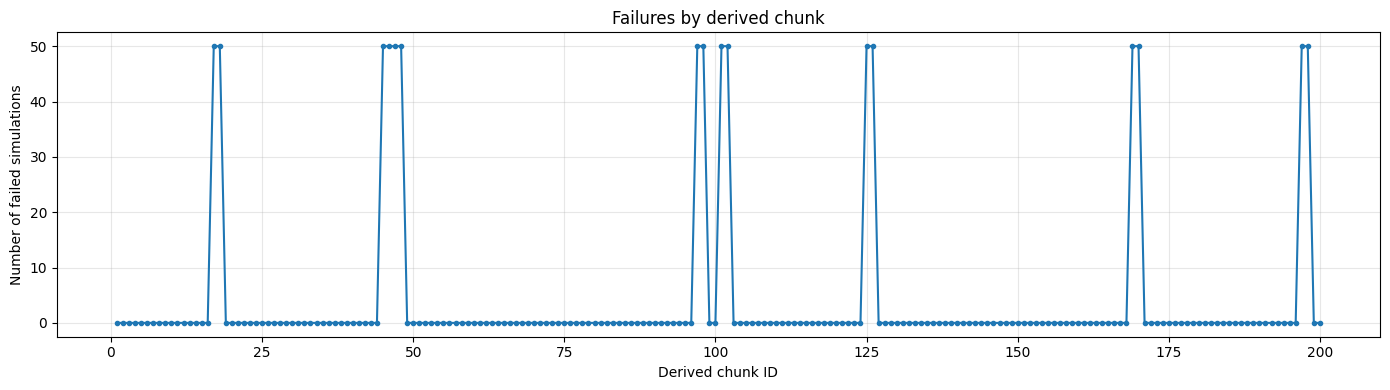

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\failures_by_derived_chunk.png


In [5]:
# ============================================================
# FAILURE RATE BY CHUNK
# ============================================================

chunk_summary = (
    df.groupby("derived_chunk_id")
    .agg(
        n_rows=("simulation_id", "count"),
        n_failed=("is_failed", "sum"),
        n_success=("is_success", "sum"),
        first_simulation_id=("simulation_id", "min"),
        last_simulation_id=("simulation_id", "max"),
        first_patient=("derived_patient_id", "min"),
        last_patient=("derived_patient_id", "max"),
    )
    .reset_index()
)

chunk_summary["failure_rate"] = chunk_summary["n_failed"] / chunk_summary["n_rows"]

display(chunk_summary.head())
display(chunk_summary.sort_values("n_failed", ascending=False).head(20))

chunk_summary_path = ANALYSIS_DIR / "failure_rate_by_derived_chunk.csv"
chunk_summary.to_csv(chunk_summary_path, index=False)
print("Saved:", chunk_summary_path)

plt.figure(figsize=(14, 4))
plt.plot(chunk_summary["derived_chunk_id"], chunk_summary["n_failed"], marker=".")
plt.xlabel("Derived chunk ID")
plt.ylabel("Number of failed simulations")
plt.title("Failures by derived chunk")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plot_path = ANALYSIS_DIR / "failures_by_derived_chunk.png"
plt.savefig(plot_path, dpi=200)
plt.show()
print("Saved:", plot_path)

,derived_patient_id,n_rows,n_failed,n_success,first_simulation_id,last_simulation_id,failure_rate
0,1,100,0,100,1,100,0.0
1,2,100,0,100,101,200,0.0
2,3,100,0,100,201,300,0.0
3,4,100,0,100,301,400,0.0
4,5,100,0,100,401,500,0.0


,derived_patient_id,n_rows,n_failed,n_success,first_simulation_id,last_simulation_id,failure_rate
23,24,100,100,0,2301,2400,1.0
22,23,100,100,0,2201,2300,1.0
8,9,100,100,0,801,900,1.0
48,49,100,100,0,4801,4900,1.0
98,99,100,100,0,9801,9900,1.0
62,63,100,100,0,6201,6300,1.0
50,51,100,100,0,5001,5100,1.0
84,85,100,100,0,8401,8500,1.0
3,4,100,0,100,301,400,0.0
2,3,100,0,100,201,300,0.0


Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\failure_rate_by_patient.csv


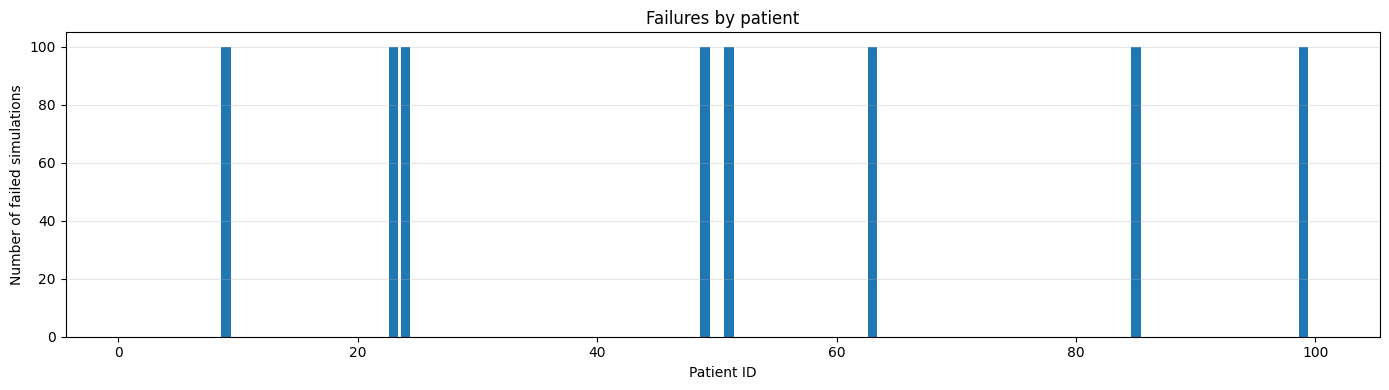

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\failures_by_patient.png


In [6]:
# ============================================================
# FAILURE RATE BY PATIENT
# ============================================================

patient_summary = (
    df.groupby("derived_patient_id")
    .agg(
        n_rows=("simulation_id", "count"),
        n_failed=("is_failed", "sum"),
        n_success=("is_success", "sum"),
        first_simulation_id=("simulation_id", "min"),
        last_simulation_id=("simulation_id", "max"),
    )
    .reset_index()
)

patient_summary["failure_rate"] = patient_summary["n_failed"] / patient_summary["n_rows"]

display(patient_summary.head())
display(patient_summary.sort_values("failure_rate", ascending=False).head(30))

patient_summary_path = ANALYSIS_DIR / "failure_rate_by_patient.csv"
patient_summary.to_csv(patient_summary_path, index=False)
print("Saved:", patient_summary_path)

plt.figure(figsize=(14, 4))
plt.bar(patient_summary["derived_patient_id"], patient_summary["n_failed"])
plt.xlabel("Patient ID")
plt.ylabel("Number of failed simulations")
plt.title("Failures by patient")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plot_path = ANALYSIS_DIR / "failures_by_patient.png"
plt.savefig(plot_path, dpi=200)
plt.show()
print("Saved:", plot_path)

,derived_variation_id,n_rows,n_failed,n_success,failure_rate
0,1,100,8,92,0.08
1,2,100,8,92,0.08
2,3,100,8,92,0.08
3,4,100,8,92,0.08
4,5,100,8,92,0.08
5,6,100,8,92,0.08
6,7,100,8,92,0.08
7,8,100,8,92,0.08
8,9,100,8,92,0.08
9,10,100,8,92,0.08


Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\failure_rate_by_variation.csv


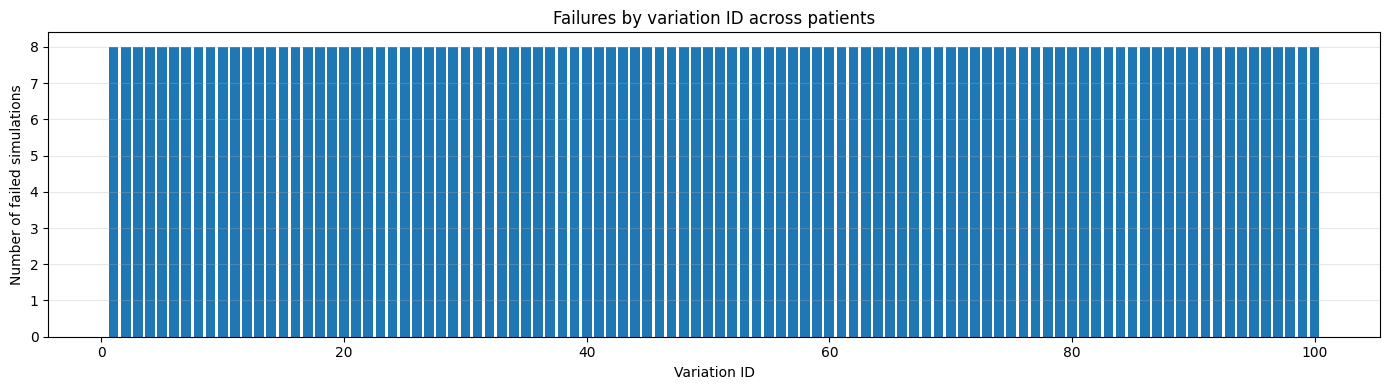

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\failures_by_variation.png


In [7]:
# ============================================================
# FAILURE RATE BY VARIATION ID
# ============================================================

variation_summary = (
    df.groupby("derived_variation_id")
    .agg(
        n_rows=("simulation_id", "count"),
        n_failed=("is_failed", "sum"),
        n_success=("is_success", "sum"),
    )
    .reset_index()
)

variation_summary["failure_rate"] = variation_summary["n_failed"] / variation_summary["n_rows"]

display(variation_summary.sort_values("failure_rate", ascending=False).head(30))

variation_summary_path = ANALYSIS_DIR / "failure_rate_by_variation.csv"
variation_summary.to_csv(variation_summary_path, index=False)
print("Saved:", variation_summary_path)

plt.figure(figsize=(14, 4))
plt.bar(variation_summary["derived_variation_id"], variation_summary["n_failed"])
plt.xlabel("Variation ID")
plt.ylabel("Number of failed simulations")
plt.title("Failures by variation ID across patients")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plot_path = ANALYSIS_DIR / "failures_by_variation.png"
plt.savefig(plot_path, dpi=200)
plt.show()
print("Saved:", plot_path)

Number of sequential failure clusters: 7


,run_length,start_simulation_id,end_simulation_id,start_patient,end_patient,start_variation,end_variation,first_chunk,last_chunk
1,200,2201,2400,23,24,1,100,45,48
0,100,801,900,9,9,1,100,17,18
2,100,4801,4900,49,49,1,100,97,98
3,100,5001,5100,51,51,1,100,101,102
4,100,6201,6300,63,63,1,100,125,126
5,100,8401,8500,85,85,1,100,169,170
6,100,9801,9900,99,99,1,100,197,198


Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\sequential_failure_runs.csv


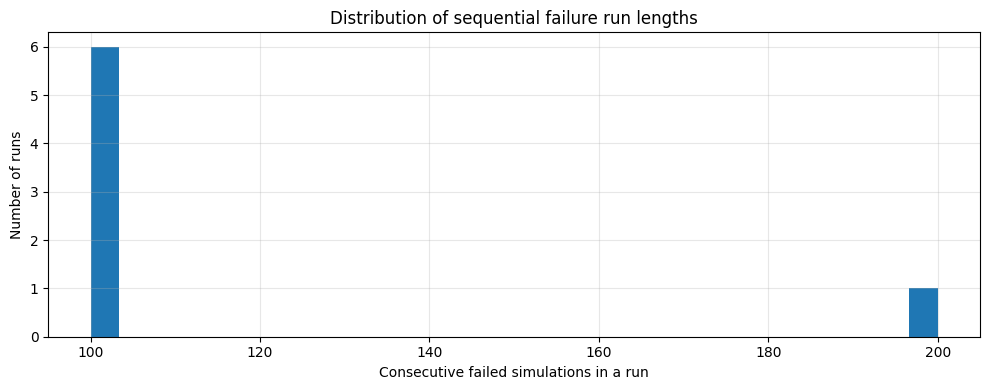

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\failure_run_length_histogram.png


In [8]:
# ============================================================
# SEQUENTIAL FAILURE RUNS / CLUSTERS
# ============================================================

ordered = df.sort_values("simulation_id").reset_index(drop=True).copy()
ordered["failure_group"] = (ordered["is_failed"] != ordered["is_failed"].shift()).cumsum()

failure_runs = (
    ordered[ordered["is_failed"]]
    .groupby("failure_group")
    .agg(
        run_length=("simulation_id", "count"),
        start_simulation_id=("simulation_id", "min"),
        end_simulation_id=("simulation_id", "max"),
        start_patient=("derived_patient_id", "min"),
        end_patient=("derived_patient_id", "max"),
        start_variation=("derived_variation_id", "min"),
        end_variation=("derived_variation_id", "max"),
        first_chunk=("derived_chunk_id", "min"),
        last_chunk=("derived_chunk_id", "max"),
    )
    .reset_index(drop=True)
    .sort_values("run_length", ascending=False)
)

print("Number of sequential failure clusters:", len(failure_runs))
display(failure_runs.head(50))

failure_runs_path = ANALYSIS_DIR / "sequential_failure_runs.csv"
failure_runs.to_csv(failure_runs_path, index=False)
print("Saved:", failure_runs_path)

plt.figure(figsize=(10, 4))
plt.hist(failure_runs["run_length"], bins=30)
plt.xlabel("Consecutive failed simulations in a run")
plt.ylabel("Number of runs")
plt.title("Distribution of sequential failure run lengths")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plot_path = ANALYSIS_DIR / "failure_run_length_histogram.png"
plt.savefig(plot_path, dpi=200)
plt.show()
print("Saved:", plot_path)

derived_variation_id,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100
derived_patient_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\failure_matrix_patient_by_variation.csv


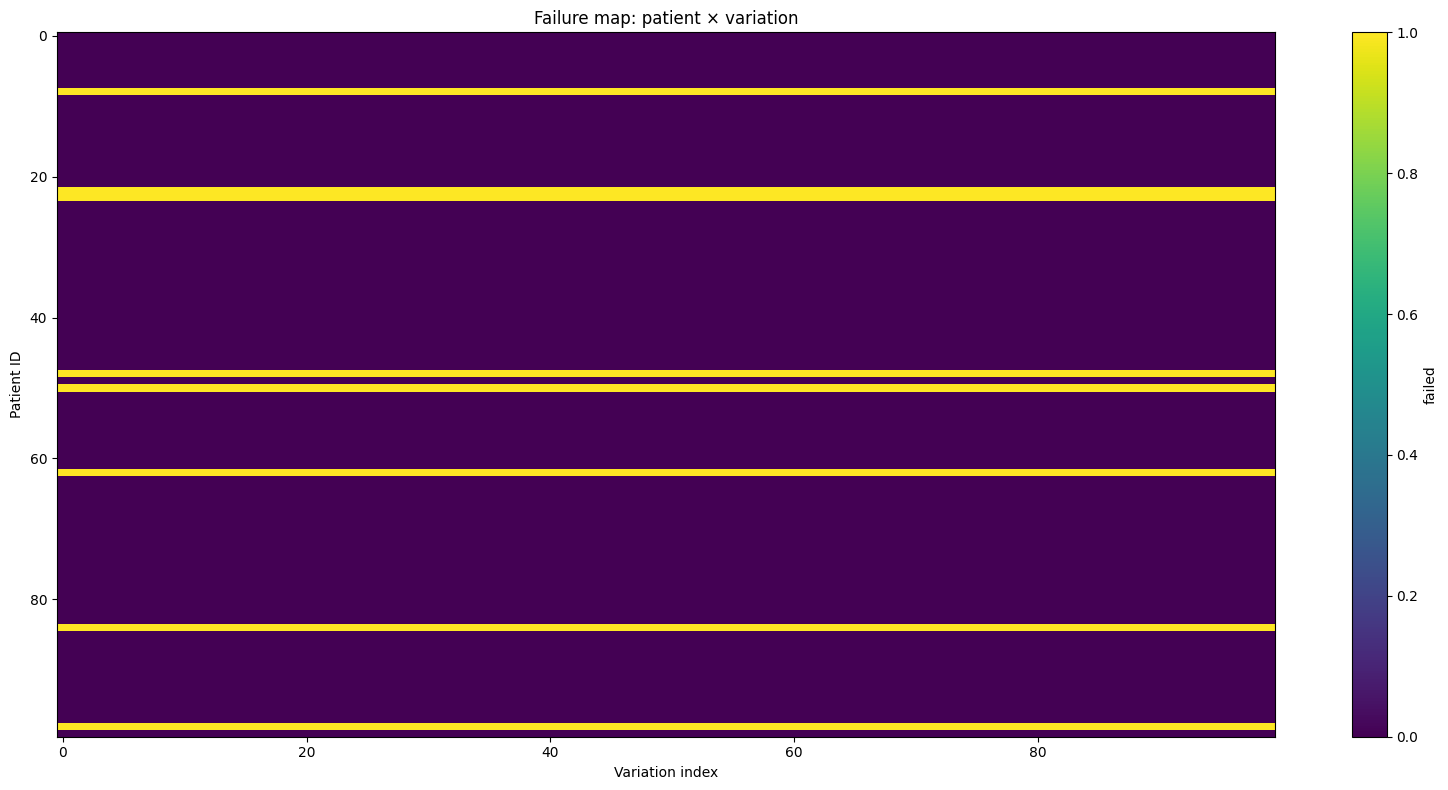

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\failure_heatmap_patient_by_variation.png


In [9]:
# ============================================================
# FAILURE HEATMAP BY PATIENT × VARIATION
# ============================================================

heat = (
    df.pivot_table(
        index="derived_patient_id",
        columns="derived_variation_id",
        values="is_failed",
        aggfunc="max",
        fill_value=False,
    )
    .astype(int)
)

display(heat.head())

heat_path = ANALYSIS_DIR / "failure_matrix_patient_by_variation.csv"
heat.to_csv(heat_path)
print("Saved:", heat_path)

plt.figure(figsize=(16, 8))
plt.imshow(heat.values, aspect="auto", interpolation="nearest")
plt.xlabel("Variation index")
plt.ylabel("Patient ID")
plt.title("Failure map: patient × variation")
plt.colorbar(label="failed")
plt.tight_layout()
plot_path = ANALYSIS_DIR / "failure_heatmap_patient_by_variation.png"
plt.savefig(plot_path, dpi=200)
plt.show()
print("Saved:", plot_path)

In [10]:
# ============================================================
# ERROR MESSAGE ANALYSIS
# ============================================================

if "error_message" in df.columns:
    failed = df[df["is_failed"]].copy()
    failed["error_message_clean"] = (
        failed["error_message"]
        .fillna("<NA>")
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    error_counts = failed["error_message_clean"].value_counts(dropna=False).reset_index()
    error_counts.columns = ["error_message_clean", "count"]

    display(error_counts.head(30))

    error_counts_path = ANALYSIS_DIR / "error_message_counts.csv"
    error_counts.to_csv(error_counts_path, index=False)
    print("Saved:", error_counts_path)

    # Short snippets are often more useful when MATLAB messages are huge.
    failed["error_snippet"] = failed["error_message_clean"].str.slice(0, 250)
    snippet_counts = failed["error_snippet"].value_counts(dropna=False).reset_index()
    snippet_counts.columns = ["error_snippet", "count"]

    display(snippet_counts.head(30))

    snippet_counts_path = ANALYSIS_DIR / "error_snippet_counts.csv"
    snippet_counts.to_csv(snippet_counts_path, index=False)
    print("Saved:", snippet_counts_path)
else:
    print("No error_message column found.")

,error_message_clean,count
0,Error using run_one_case_conditional_sampling_...,1
1,Error using run_one_case_conditional_sampling_...,1
2,Error using run_one_case_conditional_sampling_...,1
3,Error using run_one_case_conditional_sampling_...,1
4,Error using run_one_case_conditional_sampling_...,1
5,Error using run_one_case_conditional_sampling_...,1
6,Error using run_one_case_conditional_sampling_...,1
7,Error using run_one_case_conditional_sampling_...,1
8,Error using run_one_case_conditional_sampling_...,1
9,Error using run_one_case_conditional_sampling_...,1


Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\error_message_counts.csv


,error_snippet,count
0,Error using run_one_case_conditional_sampling_...,1
1,Error using run_one_case_conditional_sampling_...,1
2,Error using run_one_case_conditional_sampling_...,1
3,Error using run_one_case_conditional_sampling_...,1
4,Error using run_one_case_conditional_sampling_...,1
5,Error using run_one_case_conditional_sampling_...,1
6,Error using run_one_case_conditional_sampling_...,1
7,Error using run_one_case_conditional_sampling_...,1
8,Error using run_one_case_conditional_sampling_...,1
9,Error using run_one_case_conditional_sampling_...,1


Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\error_snippet_counts.csv


In [11]:
# ============================================================
# FAILED VS SUCCESS PARAMETER COMPARISON
# ============================================================

exclude_keywords = [
    "id",
    "seed",
    "status",
    "message",
    "name",
    "method",
    "campaign",
]

numeric_cols = []
for c in df.columns:
    if c in ["is_failed", "is_success"]:
        continue
    if any(k in c.lower() for k in exclude_keywords):
        continue
    if pd.api.types.is_numeric_dtype(df[c]):
        numeric_cols.append(c)

print("Numeric columns used:", len(numeric_cols))
print(numeric_cols)

rows = []
for c in numeric_cols:
    success_vals = df.loc[df["is_success"], c].dropna()
    failed_vals = df.loc[df["is_failed"], c].dropna()

    if len(success_vals) == 0 or len(failed_vals) == 0:
        continue

    success_mean = success_vals.mean()
    failed_mean = failed_vals.mean()
    success_std = success_vals.std()

    if success_std == 0 or pd.isna(success_std):
        effect = np.nan
    else:
        effect = (failed_mean - success_mean) / success_std

    rows.append({
        "column": c,
        "success_mean": success_mean,
        "failed_mean": failed_mean,
        "difference_failed_minus_success": failed_mean - success_mean,
        "effect_size_in_success_std": effect,
        "success_median": success_vals.median(),
        "failed_median": failed_vals.median(),
        "success_min": success_vals.min(),
        "success_max": success_vals.max(),
        "failed_min": failed_vals.min(),
        "failed_max": failed_vals.max(),
    })

param_compare = pd.DataFrame(rows)
param_compare["abs_effect_size"] = param_compare["effect_size_in_success_std"].abs()
param_compare = param_compare.sort_values("abs_effect_size", ascending=False)

display(param_compare.head(40))

param_compare_path = ANALYSIS_DIR / "failed_vs_success_numeric_parameter_comparison.csv"
param_compare.to_csv(param_compare_path, index=False)
print("Saved:", param_compare_path)

Numeric columns used: 48
['EDVLV', 'ESVLV', 'LVSV', 'LVEF', 'EDVRV', 'ESVRV', 'RVSV', 'RVEF', 'hr', 'COLV', 'SVR', 'PVR', 'CVP', 'LAP', 'MAP', 'SAP', 'DAP', 'mPAP', 'sPAP', 'dPAP', 'weight', 'Rsysven', 'mcfp', 'graft_length', 'BSA', 'k_Vtot', 'k_Vsys', 'k_Vusv_sys', 'k_Vusv_sys_ven', 'k_Vusv_pulm_ven', 'k_Ctot', 'k_Csys', 'k_Rsysven', 'k_Rpulmart', 'k_ESP_LV', 'k_ESP_RV', 'LAP_real', 'RAP_real', 'SAP_real', 'DAP_real', 'sPAP_real', 'dPAP_real', 'EDV_LV_real', 'ESV_LV_real', 'EDV_RV_real', 'ESV_RV_real', 'CO_real', 'position_in_chunk']


,column,success_mean,failed_mean,difference_failed_minus_success,effect_size_in_success_std,success_median,failed_median,success_min,success_max,failed_min,failed_max,abs_effect_size
13,LAP,22.225932,27.667482,5.441549e+00,0.994032,22.606643,28.887443,9.735921,33.149077,18.484818,29.814644,0.994032
7,RVEF,58.492691,54.156853,-4.335838e+00,-0.551449,58.451661,54.083168,40.449486,78.793581,46.386769,61.262679,0.551449
8,hr,119.945652,106.250000,-1.369565e+01,-0.544863,119.500000,103.500000,64.000000,171.000000,72.000000,148.000000,0.544863
21,Rsysven,0.154815,0.100110,-5.470494e-02,-0.509703,0.132047,0.124489,0.007169,0.546390,-0.099407,0.167578,0.509703
20,weight,15.163855,16.583712,1.419857e+00,0.487661,15.189326,16.676809,8.481686,21.843913,11.817302,21.634964,0.487661
24,BSA,7.105287,7.432431,3.271436e-01,0.471041,7.145123,7.485665,5.339278,8.568537,6.302322,8.527457,0.471041
9,COLV,2438.638256,2024.898195,-4.137401e+02,-0.464940,2426.545031,1914.337498,1077.877746,4873.660759,1272.775858,3002.583492,0.464940
3,LVEF,17.760781,15.323894,-2.436887e+00,-0.368771,16.926500,14.652247,5.215422,43.504059,11.812226,23.895411,0.368771
18,sPAP,49.549482,52.649681,3.100199e+00,0.290644,48.349104,52.257830,27.797155,69.746761,38.136052,66.133482,0.290644
12,CVP,12.072422,13.308756,1.236334e+00,0.274246,12.853383,12.605553,1.487220,23.753560,5.245420,23.366402,0.274246


Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\failed_vs_success_numeric_parameter_comparison.csv


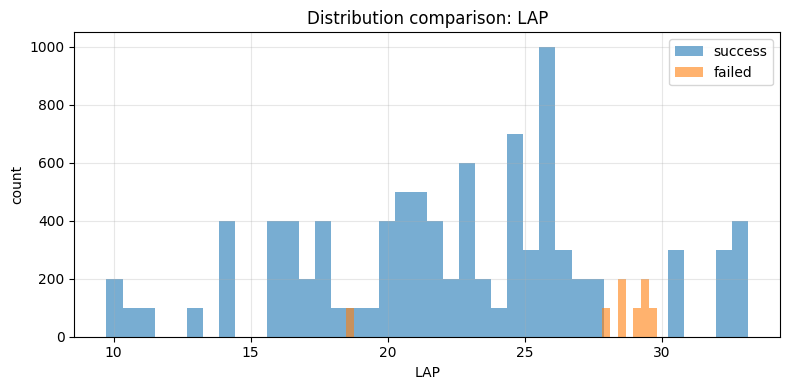

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\distribution_success_vs_failed_LAP.png


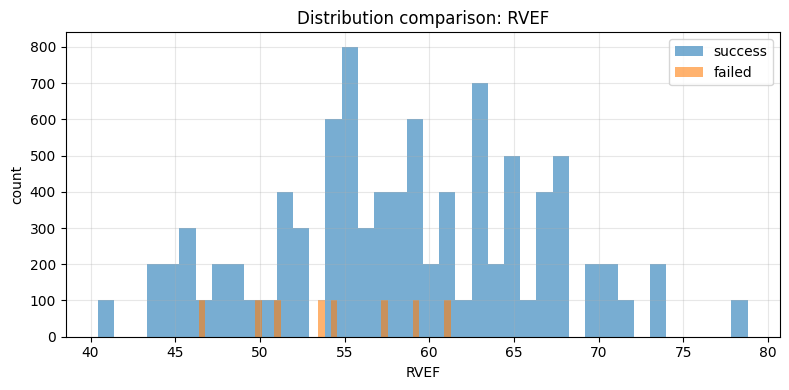

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\distribution_success_vs_failed_RVEF.png


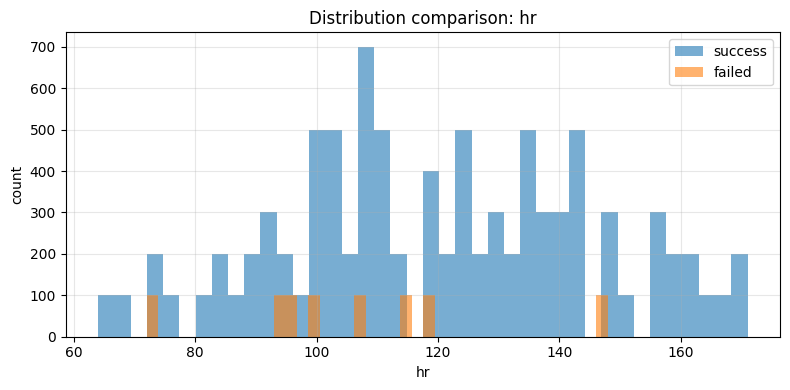

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\distribution_success_vs_failed_hr.png


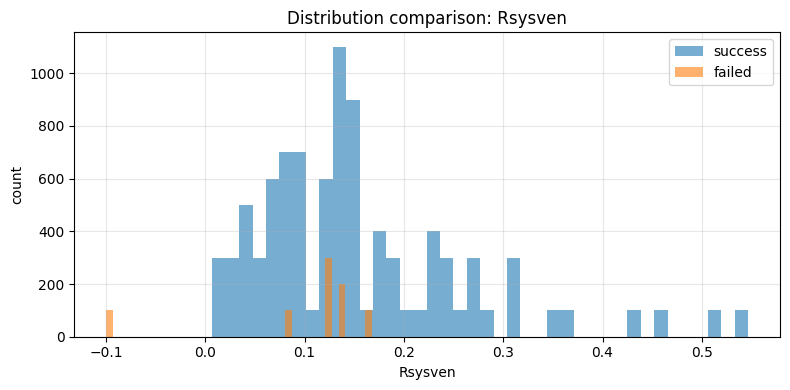

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\distribution_success_vs_failed_Rsysven.png


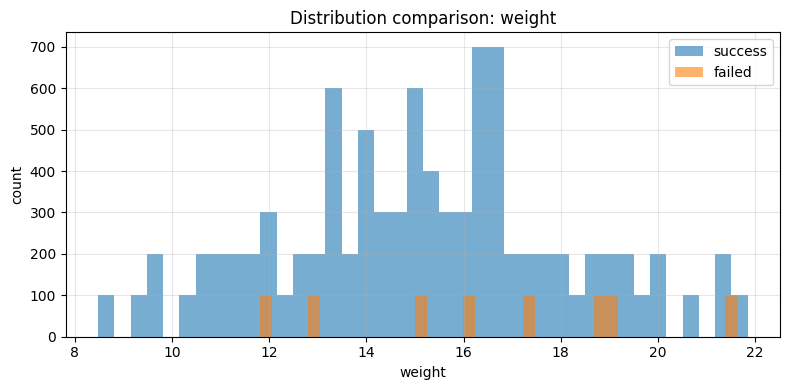

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\distribution_success_vs_failed_weight.png


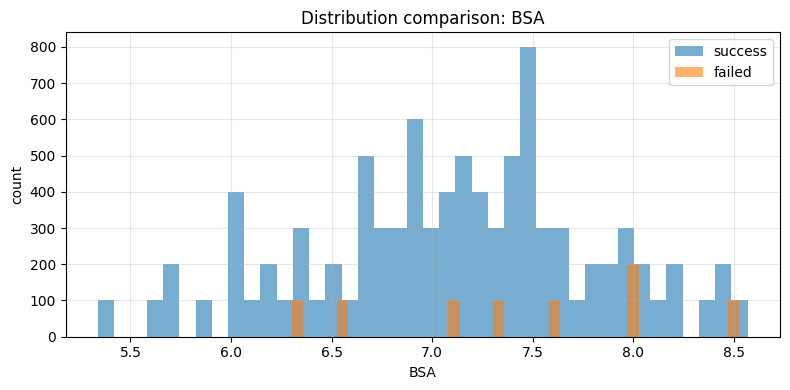

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\distribution_success_vs_failed_BSA.png


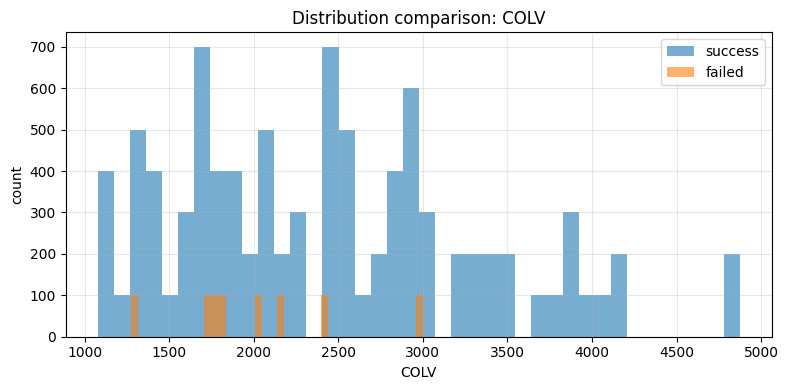

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\distribution_success_vs_failed_COLV.png


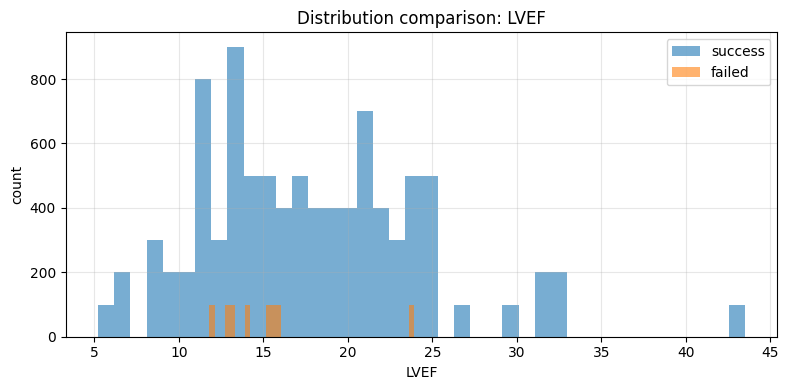

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\distribution_success_vs_failed_LVEF.png


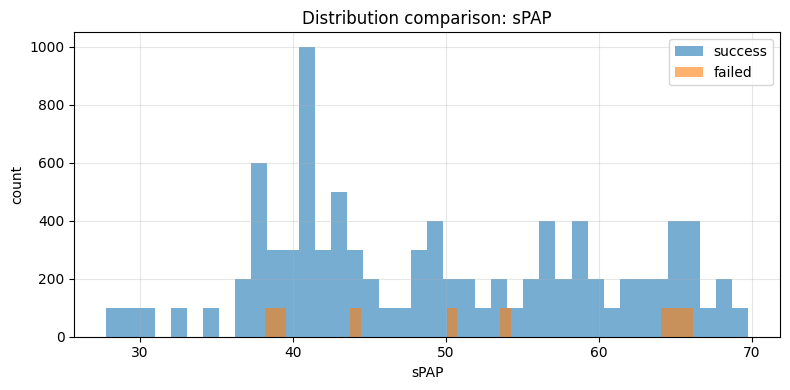

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\distribution_success_vs_failed_sPAP.png


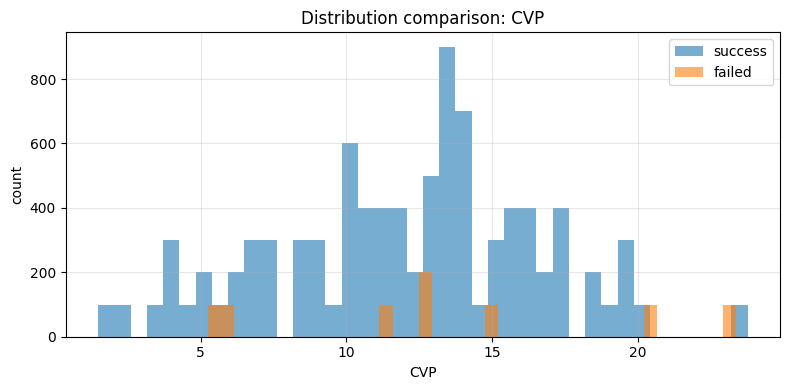

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\distribution_success_vs_failed_CVP.png


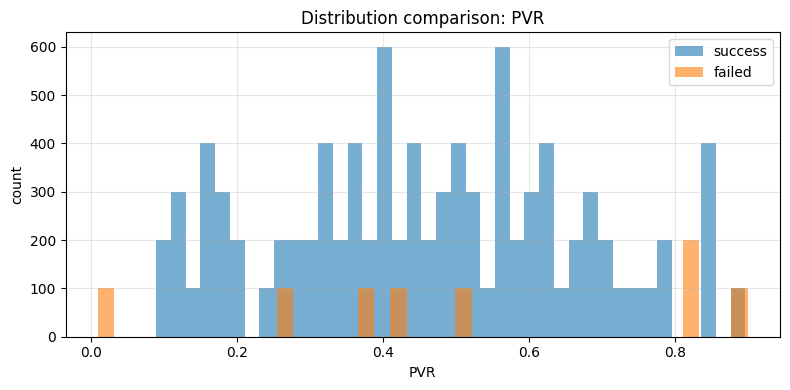

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\distribution_success_vs_failed_PVR.png


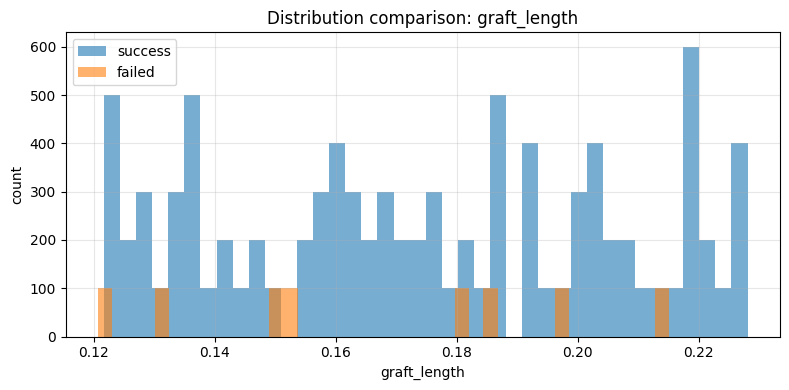

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\distribution_success_vs_failed_graft_length.png


In [12]:
# ============================================================
# TOP PARAMETER DISTRIBUTIONS FOR FAILURES
# ============================================================

top_cols = param_compare["column"].head(12).tolist()

for col in top_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df.loc[df["is_success"], col].dropna(), bins=40, alpha=0.6, label="success")
    plt.hist(df.loc[df["is_failed"], col].dropna(), bins=40, alpha=0.6, label="failed")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.title(f"Distribution comparison: {col}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    safe_col = re.sub(r"[^A-Za-z0-9_]+", "_", col)
    plot_path = ANALYSIS_DIR / f"distribution_success_vs_failed_{safe_col}.png"
    plt.savefig(plot_path, dpi=200)
    plt.show()
    print("Saved:", plot_path)

In [13]:
# ============================================================
# PATIENT-LEVEL TARGETS FOR HIGH-FAILURE PATIENTS
# ============================================================

patient_cols = [
    "EDVLV", "ESVLV", "LVSV", "LVEF",
    "EDVRV", "ESVRV", "RVSV", "RVEF",
    "hr", "COLV", "SVR", "PVR", "CVP", "LAP",
    "MAP", "SAP", "DAP", "mPAP", "sPAP", "dPAP",
    "weight", "Rsysven", "mcfp", "graft_length", "BSA"
]

patient_cols = [c for c in patient_cols if c in df.columns]

# Patient targets are repeated for all variations, so take first row per patient.
patient_targets = (
    df.sort_values("simulation_id")
    .groupby("derived_patient_id")[patient_cols]
    .first()
    .reset_index()
)

patient_targets = patient_targets.merge(
    patient_summary[["derived_patient_id", "n_failed", "failure_rate"]],
    on="derived_patient_id",
    how="left"
)

display(patient_targets.sort_values("failure_rate", ascending=False).head(30))

patient_targets_path = ANALYSIS_DIR / "patient_targets_with_failure_rate.csv"
patient_targets.to_csv(patient_targets_path, index=False)
print("Saved:", patient_targets_path)

# Correlation between patient-level targets and failure rate
corr_rows = []
for c in patient_cols:
    if patient_targets[c].nunique(dropna=True) > 1:
        corr = patient_targets[[c, "failure_rate"]].corr().iloc[0, 1]
        corr_rows.append({"column": c, "corr_with_failure_rate": corr})

patient_corr = pd.DataFrame(corr_rows)
patient_corr["abs_corr"] = patient_corr["corr_with_failure_rate"].abs()
patient_corr = patient_corr.sort_values("abs_corr", ascending=False)

display(patient_corr)

patient_corr_path = ANALYSIS_DIR / "patient_target_correlations_with_failure_rate.csv"
patient_corr.to_csv(patient_corr_path, index=False)
print("Saved:", patient_corr_path)

,derived_patient_id,EDVLV,ESVLV,LVSV,LVEF,EDVRV,ESVRV,RVSV,RVEF,hr,COLV,SVR,PVR,CVP,LAP,MAP,SAP,DAP,mPAP,sPAP,dPAP,weight,Rsysven,mcfp,graft_length,BSA,n_failed,failure_rate
23,24,126.012996,109.317243,16.695753,13.249231,30.695080,13.999326,16.695753,54.392279,107,1786.445622,1.614037,0.826726,12.521943,29.814644,60.578444,80.541228,50.597052,54.429662,64.429662,44.429662,16.088776,0.140833,16.715125,0.120690,7.353650,100,1.0
22,23,116.777785,98.635189,18.142595,15.535999,33.738565,15.595970,18.142595,53.774057,119,2158.968854,2.071195,0.820578,5.245420,28.606774,79.772841,96.768984,71.274769,58.133482,66.133482,50.133482,21.634964,0.083285,8.242231,0.186020,8.527457,100,1.0
8,9,113.665279,95.495237,18.170042,15.985570,31.612582,13.442540,18.170042,57.477248,100,1817.004237,1.787216,0.266225,5.889927,28.023185,60.012915,78.876837,50.580955,36.085394,44.085394,28.085394,17.264842,0.167578,10.964766,0.153512,7.617680,100,1.0
48,49,156.231925,132.467598,23.764326,15.210929,40.093072,16.328745,23.764326,59.272900,72,1711.031502,0.861122,0.899011,20.418650,29.387117,44.975437,66.032515,34.446898,55.024392,65.024392,45.024392,18.933631,0.126823,24.035283,0.130858,7.977345,100,1.0
98,99,114.628430,101.088261,13.540169,11.812226,29.189722,15.649553,13.540169,46.386769,94,1272.775858,1.184671,0.502110,23.366402,18.484818,48.496740,70.583900,37.453160,29.136052,38.136052,20.136052,12.816616,-0.099407,21.257696,0.149732,6.563389,100,1.0
62,63,186.882811,160.544359,26.338452,14.093566,52.943693,26.605241,26.338452,49.748044,114,3002.583492,1.374623,0.010138,11.465646,29.365486,80.256008,96.267484,72.250270,29.872804,38.872804,20.872804,11.817302,0.138187,18.380945,0.197771,6.302322,100,1.0
50,51,106.122205,92.529835,13.592370,12.808224,22.187032,8.594662,13.592370,61.262679,148,2011.670760,1.618835,0.414907,12.689163,28.489716,66.965224,88.471648,56.212011,42.400655,50.400655,34.400655,15.074406,0.121427,16.760352,0.180647,7.118058,100,1.0
84,85,106.309868,80.906689,25.403180,23.895411,49.867997,24.464817,25.403180,50.940846,96,2438.705234,1.123298,0.367742,14.872900,29.168113,60.529465,77.601473,51.993461,44.115005,54.115005,34.115005,19.039156,0.122155,19.837896,0.215096,7.999545,100,1.0
3,4,111.340275,84.407051,26.933224,24.190010,49.973155,23.039930,26.933224,53.895385,102,2747.188867,1.750707,0.400323,13.384048,32.302088,93.542767,112.131064,84.248619,50.631474,58.631474,42.631474,19.569438,0.099579,17.943429,0.166053,8.110182,0,0.0
2,3,199.653148,187.129154,12.523994,6.272876,19.465642,6.941648,12.523994,64.338972,134,1678.215202,1.490384,0.434376,19.429144,33.149077,61.115550,79.997472,51.674589,45.298673,55.298673,35.298673,17.033462,0.270467,26.994185,0.202999,7.566463,0,0.0


Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\patient_targets_with_failure_rate.csv


,column,corr_with_failure_rate,abs_corr
13,LAP,0.266292,0.266292
7,RVEF,-0.151816,0.151816
8,hr,-0.148107,0.148107
21,Rsysven,-0.139547,0.139547
20,weight,0.130473,0.130473
9,COLV,-0.128741,0.128741
24,BSA,0.126597,0.126597
3,LVEF,-0.102512,0.102512
18,sPAP,0.078457,0.078457
12,CVP,0.072179,0.072179


Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\patient_target_correlations_with_failure_rate.csv


Tunable columns: ['k_Vtot', 'k_Vsys', 'k_Vusv_sys', 'k_Vusv_sys_ven', 'k_Vusv_pulm_ven', 'k_Ctot', 'k_Csys', 'k_Rsysven', 'k_Rpulmart', 'k_ESP_LV', 'k_ESP_RV']


,column,success_mean,failed_mean,success_median,failed_median,success_min,success_max,failed_min,failed_max,effect_size,abs_effect_size
5,k_Ctot,2.149955,2.149819,2.150014,2.150743,1.730021,2.569902,1.730334,2.568739,-0.000559,0.000559
6,k_Csys,0.857504,0.857483,0.857503,0.857478,0.790023,0.924981,0.790118,0.924999,-0.000541,0.000541
4,k_Vusv_pulm_ven,0.883003,0.883021,0.882991,0.882977,0.806012,0.959994,0.806561,0.959955,0.000405,0.000405
2,k_Vusv_sys,0.839499,0.839517,0.839482,0.839527,0.751006,0.927937,0.751071,0.927949,0.000346,0.000346
3,k_Vusv_sys_ven,0.944998,0.944990,0.944998,0.945002,0.901001,0.988999,0.901041,0.988923,-0.000320,0.000320
10,k_ESP_RV,1.000002,0.999994,0.999995,0.999842,0.950001,1.049995,0.950193,1.049816,-0.000265,0.000265
9,k_ESP_LV,0.964992,0.964996,0.965005,0.964829,0.900022,1.029974,0.900198,1.029799,0.000095,0.000095
0,k_Vtot,72.500353,72.500815,72.500154,72.468708,60.201519,84.793873,60.211658,84.783369,0.000065,0.000065
7,k_Rsysven,0.059999,0.059999,0.060001,0.059977,0.049001,0.070997,0.049022,0.070985,-0.000040,0.000040
8,k_Rpulmart,0.655001,0.654998,0.654998,0.654812,0.520098,0.789965,0.520132,0.789982,-0.000040,0.000040


Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\tunable_failed_vs_success_summary.csv


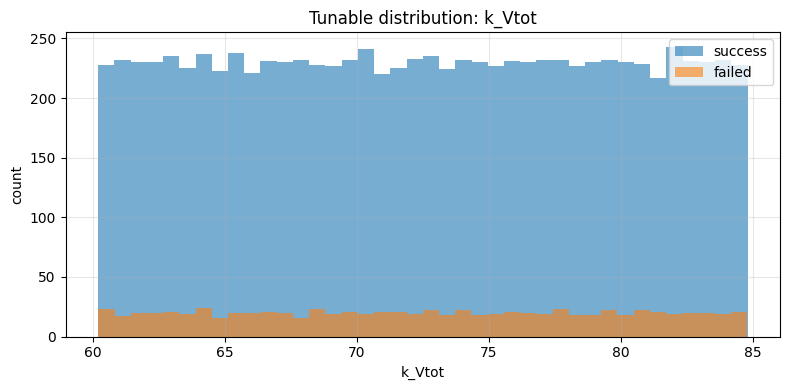

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\tunable_distribution_k_Vtot.png


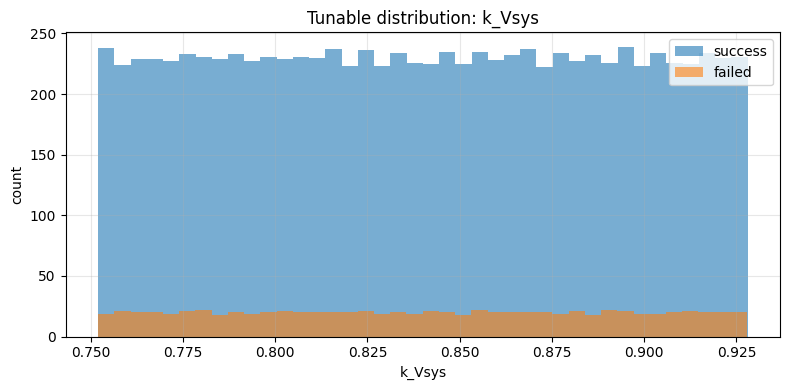

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\tunable_distribution_k_Vsys.png


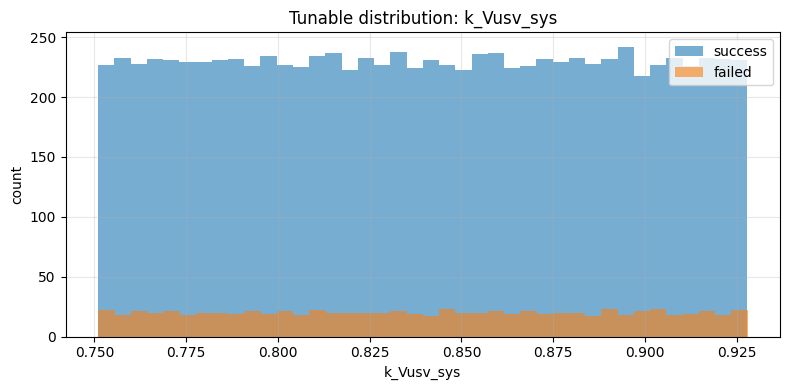

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\tunable_distribution_k_Vusv_sys.png


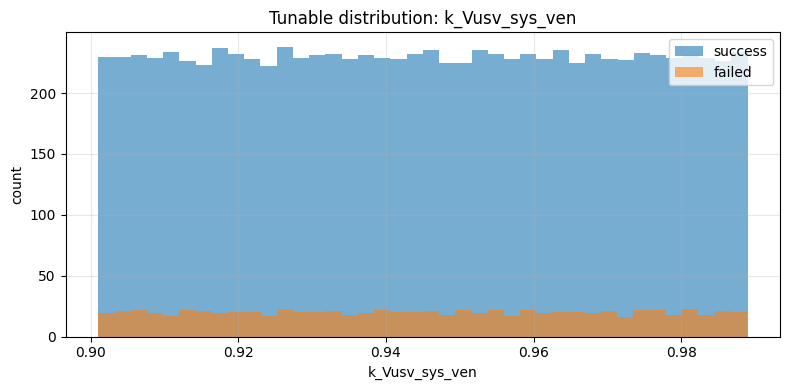

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\tunable_distribution_k_Vusv_sys_ven.png


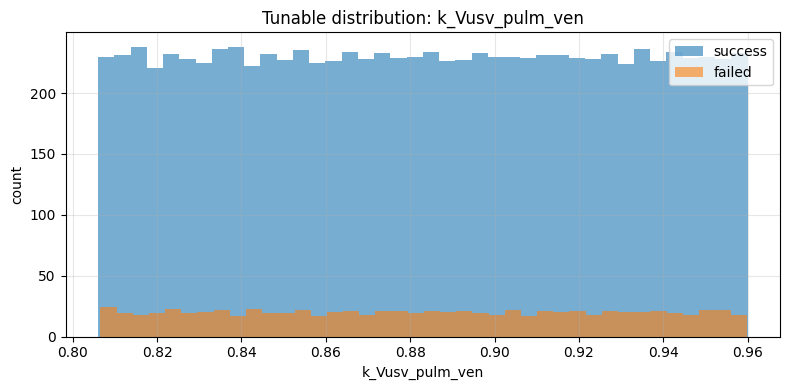

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\tunable_distribution_k_Vusv_pulm_ven.png


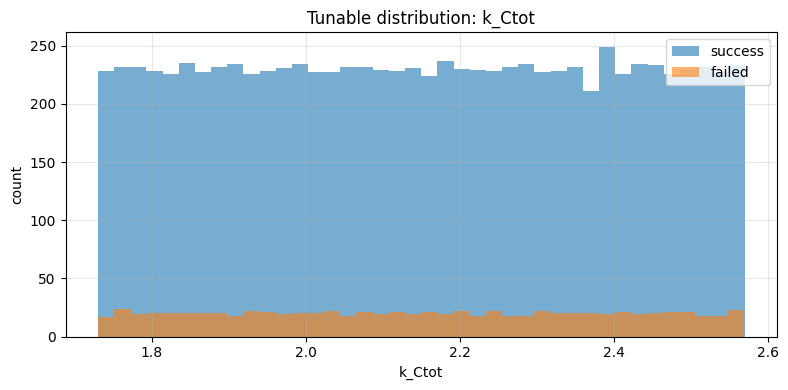

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\tunable_distribution_k_Ctot.png


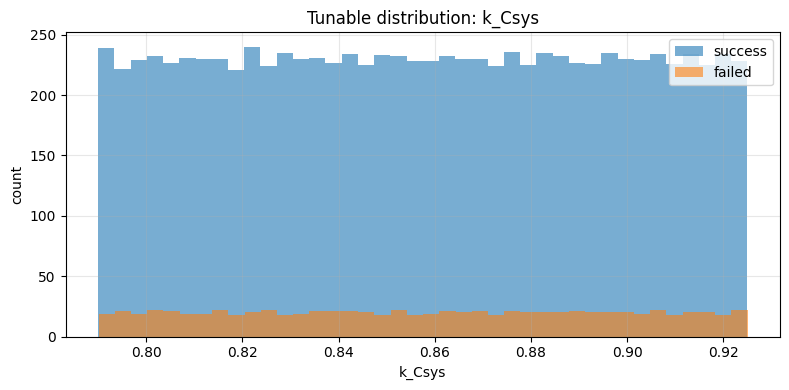

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\tunable_distribution_k_Csys.png


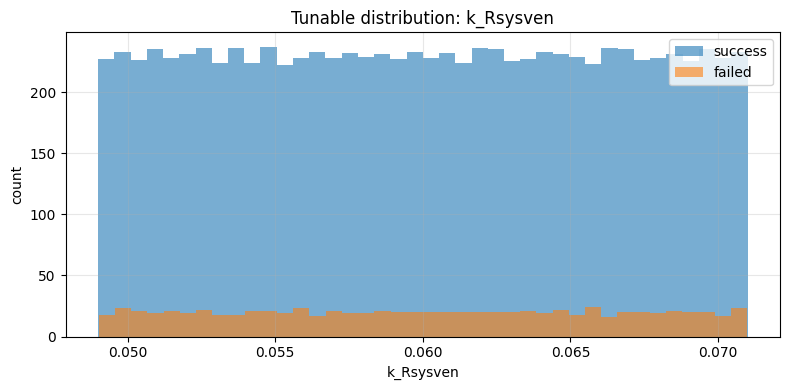

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\tunable_distribution_k_Rsysven.png


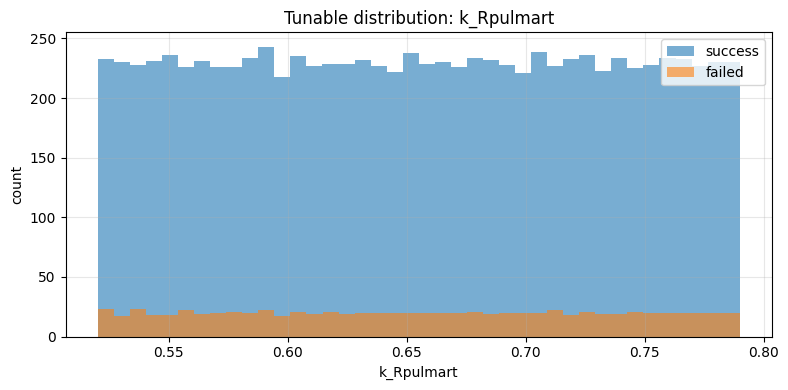

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\tunable_distribution_k_Rpulmart.png


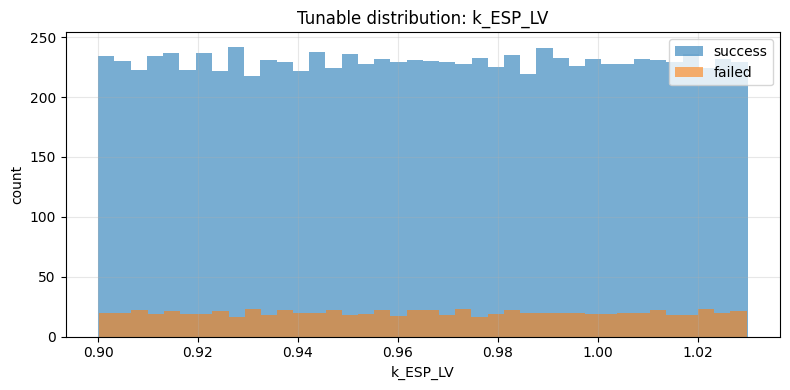

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\tunable_distribution_k_ESP_LV.png


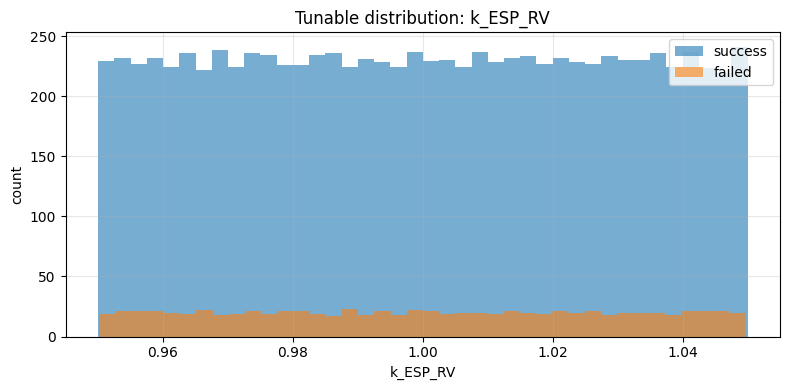

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\tunable_distribution_k_ESP_RV.png


In [14]:
# ============================================================
# TUNABLE COEFFICIENT ANALYSIS
# ============================================================

tunable_cols = [
    "k_Vtot", "k_Vsys", "k_Vusv_sys", "k_Vusv_sys_ven", "k_Vusv_pulm_ven",
    "k_Ctot", "k_Csys", "k_Rsysven", "k_Rpulmart", "k_ESP_LV", "k_ESP_RV"
]
tunable_cols = [c for c in tunable_cols if c in df.columns]

print("Tunable columns:", tunable_cols)

if tunable_cols:
    rows = []
    for c in tunable_cols:
        s = df.loc[df["is_success"], c].dropna()
        f = df.loc[df["is_failed"], c].dropna()
        rows.append({
            "column": c,
            "success_mean": s.mean(),
            "failed_mean": f.mean(),
            "success_median": s.median(),
            "failed_median": f.median(),
            "success_min": s.min(),
            "success_max": s.max(),
            "failed_min": f.min(),
            "failed_max": f.max(),
            "effect_size": (f.mean() - s.mean()) / s.std() if s.std() else np.nan,
        })

    tunable_summary = pd.DataFrame(rows)
    tunable_summary["abs_effect_size"] = tunable_summary["effect_size"].abs()
    tunable_summary = tunable_summary.sort_values("abs_effect_size", ascending=False)
    display(tunable_summary)

    tunable_summary_path = ANALYSIS_DIR / "tunable_failed_vs_success_summary.csv"
    tunable_summary.to_csv(tunable_summary_path, index=False)
    print("Saved:", tunable_summary_path)

    for c in tunable_cols:
        plt.figure(figsize=(8, 4))
        plt.hist(df.loc[df["is_success"], c].dropna(), bins=40, alpha=0.6, label="success")
        plt.hist(df.loc[df["is_failed"], c].dropna(), bins=40, alpha=0.6, label="failed")
        plt.xlabel(c)
        plt.ylabel("count")
        plt.title(f"Tunable distribution: {c}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plot_path = ANALYSIS_DIR / f"tunable_distribution_{c}.png"
        plt.savefig(plot_path, dpi=200)
        plt.show()
        print("Saved:", plot_path)

Confusion matrix:
[[1840    0]
 [   0  160]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1840
           1       1.00      1.00      1.00       160

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

ROC AUC: 1.0


,feature,importance
17,LAP,0.198290
11,RVEF,0.081881
25,Rsysven,0.065901
7,LVEF,0.063111
4,EDVLV,0.058611
13,COLV,0.048372
9,ESVRV,0.046215
10,RVSV,0.039259
5,ESVLV,0.037912
12,hr,0.036286


Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\random_forest_failure_classifier_importances.csv


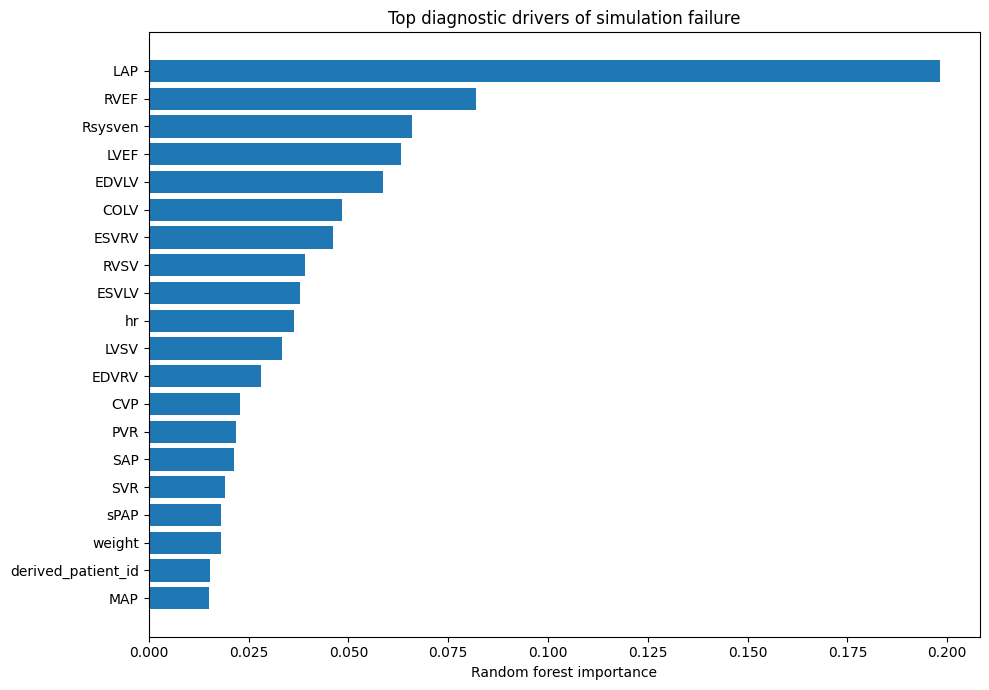

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\failure_classifier_feature_importance.png


In [16]:
# ============================================================
# QUICK CLASSIFIER TO IDENTIFY FAILURE DRIVERS
# ============================================================

# This optional model is not for final prediction. It is a diagnostic:
# which variables best separate failed vs success simulations?

try:
    from sklearn.model_selection import train_test_split
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

    feature_candidates = []
    for c in df.columns:
        if c in [
            "simulation_status", "error_message", "campaign_name", "sampling_method",
            "is_failed", "is_success"
        ]:
            continue
        if c.endswith("_real"):
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            feature_candidates.append(c)

    X = df[feature_candidates].copy()
    y = df["is_failed"].astype(int)

    # Simple missing fill
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    clf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
        max_depth=None,
        min_samples_leaf=3,
    )

    clf.fit(X_train, y_train)

    pred = clf.predict(X_test)
    proba = clf.predict_proba(X_test)[:, 1]

    print("Confusion matrix:")
    print(confusion_matrix(y_test, pred))

    print("\nClassification report:")
    print(classification_report(y_test, pred))

    print("ROC AUC:", roc_auc_score(y_test, proba))

    importances = pd.DataFrame({
        "feature": feature_candidates,
        "importance": clf.feature_importances_,
    }).sort_values("importance", ascending=False)

    display(importances.head(30))

    importances_path = ANALYSIS_DIR / "random_forest_failure_classifier_importances.csv"
    importances.to_csv(importances_path, index=False)
    print("Saved:", importances_path)

    plt.figure(figsize=(10, 7))
    top = importances.head(20).iloc[::-1]
    plt.barh(top["feature"], top["importance"])
    plt.xlabel("Random forest importance")
    plt.title("Top diagnostic drivers of simulation failure")
    plt.tight_layout()
    plot_path = ANALYSIS_DIR / "failure_classifier_feature_importance.png"
    plt.savefig(plot_path, dpi=200)
    plt.show()
    print("Saved:", plot_path)

except Exception as e:
    print("Skipping classifier analysis because of error:")
    print(e)

In [17]:
# ============================================================
# FINAL INTERPRETATION HELPER
# ============================================================

print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

n_failed = int(df["is_failed"].sum())
n_success = int(df["is_success"].sum())

print(f"Rows: {len(df):,}")
print(f"Successes: {n_success:,}")
print(f"Failures: {n_failed:,}")
print(f"Failure rate: {n_failed / len(df):.2%}")

print("\nTop failure patients:")
display(patient_summary.sort_values("failure_rate", ascending=False).head(10))

print("\nTop sequential failure runs:")
display(failure_runs.head(10))

print("\nTop numeric differences between failed and successful rows:")
display(param_compare.head(15))

if "error_message" in df.columns:
    print("\nTop error snippets:")
    display(snippet_counts.head(10))

print("\nInterpretation notes:")
print("- If failures are grouped by patient_id, the patient target physiology is likely driving instability.")
print("- If failures are grouped by variation_id across many patients, some LHS tunable combination/range is likely unstable.")
print("- If failures are grouped by derived_chunk_id but not patient/variation, inspect cluster/log execution.")
print("- If failed/success distributions differ strongly for tunables, tighten or condition those parameter bounds.")
print("- If failed/success distributions differ strongly for patient targets, some generated patients are outside the stable model manifold.")

FINAL SUMMARY
Rows: 10,000
Successes: 9,200
Failures: 800
Failure rate: 8.00%

Top failure patients:


,derived_patient_id,n_rows,n_failed,n_success,first_simulation_id,last_simulation_id,failure_rate
23,24,100,100,0,2301,2400,1.0
22,23,100,100,0,2201,2300,1.0
8,9,100,100,0,801,900,1.0
48,49,100,100,0,4801,4900,1.0
98,99,100,100,0,9801,9900,1.0
62,63,100,100,0,6201,6300,1.0
50,51,100,100,0,5001,5100,1.0
84,85,100,100,0,8401,8500,1.0
3,4,100,0,100,301,400,0.0
2,3,100,0,100,201,300,0.0



Top sequential failure runs:


,run_length,start_simulation_id,end_simulation_id,start_patient,end_patient,start_variation,end_variation,first_chunk,last_chunk
1,200,2201,2400,23,24,1,100,45,48
0,100,801,900,9,9,1,100,17,18
2,100,4801,4900,49,49,1,100,97,98
3,100,5001,5100,51,51,1,100,101,102
4,100,6201,6300,63,63,1,100,125,126
5,100,8401,8500,85,85,1,100,169,170
6,100,9801,9900,99,99,1,100,197,198



Top numeric differences between failed and successful rows:


,column,success_mean,failed_mean,difference_failed_minus_success,effect_size_in_success_std,success_median,failed_median,success_min,success_max,failed_min,failed_max,abs_effect_size
13,LAP,22.225932,27.667482,5.441549,0.994032,22.606643,28.887443,9.735921,33.149077,18.484818,29.814644,0.994032
7,RVEF,58.492691,54.156853,-4.335838,-0.551449,58.451661,54.083168,40.449486,78.793581,46.386769,61.262679,0.551449
8,hr,119.945652,106.250000,-13.695652,-0.544863,119.500000,103.500000,64.000000,171.000000,72.000000,148.000000,0.544863
21,Rsysven,0.154815,0.100110,-0.054705,-0.509703,0.132047,0.124489,0.007169,0.546390,-0.099407,0.167578,0.509703
20,weight,15.163855,16.583712,1.419857,0.487661,15.189326,16.676809,8.481686,21.843913,11.817302,21.634964,0.487661
24,BSA,7.105287,7.432431,0.327144,0.471041,7.145123,7.485665,5.339278,8.568537,6.302322,8.527457,0.471041
9,COLV,2438.638256,2024.898195,-413.740061,-0.464940,2426.545031,1914.337498,1077.877746,4873.660759,1272.775858,3002.583492,0.464940
3,LVEF,17.760781,15.323894,-2.436887,-0.368771,16.926500,14.652247,5.215422,43.504059,11.812226,23.895411,0.368771
18,sPAP,49.549482,52.649681,3.100199,0.290644,48.349104,52.257830,27.797155,69.746761,38.136052,66.133482,0.290644
12,CVP,12.072422,13.308756,1.236334,0.274246,12.853383,12.605553,1.487220,23.753560,5.245420,23.366402,0.274246



Top error snippets:


,error_snippet,count
0,Error using run_one_case_conditional_sampling_...,1
1,Error using run_one_case_conditional_sampling_...,1
2,Error using run_one_case_conditional_sampling_...,1
3,Error using run_one_case_conditional_sampling_...,1
4,Error using run_one_case_conditional_sampling_...,1
5,Error using run_one_case_conditional_sampling_...,1
6,Error using run_one_case_conditional_sampling_...,1
7,Error using run_one_case_conditional_sampling_...,1
8,Error using run_one_case_conditional_sampling_...,1
9,Error using run_one_case_conditional_sampling_...,1



Interpretation notes:
- If failures are grouped by patient_id, the patient target physiology is likely driving instability.
- If failures are grouped by variation_id across many patients, some LHS tunable combination/range is likely unstable.
- If failures are grouped by derived_chunk_id but not patient/variation, inspect cluster/log execution.
- If failed/success distributions differ strongly for tunables, tighten or condition those parameter bounds.
- If failed/success distributions differ strongly for patient targets, some generated patients are outside the stable model manifold.


# Conclusion: 

Errors are derived from patients. All 800 errors come from 8 patients (100 each), suggesting that the conditional sampling has an 8% failure rate whereas the tunable params all fail per patient because of the patients conditional sampling. 

The 8 patient id's: 
23,22,8,48,98,62,50,84


# Analyze failed patients config: 

In [29]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIG / PATHS
# ============================================================

cwd = Path.cwd()

# Works whether notebook is run from project root or 07_Conditional_Sampling_Strategy
if cwd.name == "07_Conditional_Sampling_Strategy":
    ROOT = cwd.parent
else:
    ROOT = cwd

CAMPAIGN_NAME = "conditional_sampling_100_patients_100_variations_v1"

PATIENTS_PATH = (
    ROOT
    / "01_Data"
    / "Conditional_Sampling"
    / "patients"
    / "conditional_sampling_100_patients.csv"
)

RESULTS_PATH = (
    ROOT
    / "01_Data"
    / "Conditional_Sampling"
    / "simulation_results"
    / CAMPAIGN_NAME
    / f"{CAMPAIGN_NAME}_FULL_DATASET.csv"
)

ANALYSIS_DIR = (
    ROOT
    / "01_Data"
    / "Conditional_Sampling"
    / "simulation_results"
    / CAMPAIGN_NAME
    / "analysis_07E"
    / "failed_patient_config_analysis"
)

ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("Patients path:", PATIENTS_PATH)
print("Patients exists:", PATIENTS_PATH.exists())
print("Results path:", RESULTS_PATH)
print("Results exists:", RESULTS_PATH.exists())
print("Analysis dir:", ANALYSIS_DIR)

ROOT: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project
Patients path: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\patients\conditional_sampling_100_patients.csv
Patients exists: True
Results path: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\conditional_sampling_100_patients_100_variations_v1_FULL_DATASET.csv
Results exists: True
Analysis dir: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07E\failed_patient_config_analysis


In [30]:
# ============================================================
# LOAD DATA
# ============================================================

patients_df = pd.read_csv(PATIENTS_PATH)
results_df = pd.read_csv(RESULTS_PATH)

print("Patients shape:", patients_df.shape)
print("Results shape:", results_df.shape)

display(patients_df.head())
display(results_df.head())

Patients shape: (100, 26)
Results shape: (10000, 55)


,patient_id,EDVLV,ESVLV,LVSV,LVEF,EDVRV,ESVRV,RVSV,RVEF,hr,COLV,SVR,PVR,CVP,LAP,MAP,SAP,DAP,mPAP,sPAP,dPAP,weight,Rsysven,mcfp,graft_length,BSA
0,1,182.585699,157.386830,25.198868,13.801118,56.129970,30.931102,25.198868,44.893785,102,2570.284572,1.198952,0.692958,15.230286,26.024555,66.591067,88.524436,55.624382,55.709560,62.709560,48.709560,15.253845,0.314536,28.704408,0.186144,7.160298
1,2,121.695891,105.971879,15.724012,12.920742,28.326012,12.602000,15.724012,55.510856,138,2169.913639,2.103773,0.089663,16.418482,22.535666,92.501900,110.231088,83.637307,25.778358,32.778358,18.778358,18.382576,0.235718,24.943261,0.128182,7.860399
2,3,199.653148,187.129154,12.523994,6.272876,19.465642,6.941648,12.523994,64.338972,134,1678.215202,1.490384,0.434376,19.429144,33.149077,61.115550,79.997472,51.674589,45.298673,55.298673,35.298673,17.033462,0.270467,26.994185,0.202999,7.566463
3,4,111.340275,84.407051,26.933224,24.190010,49.973155,23.039930,26.933224,53.895385,102,2747.188867,1.750707,0.400323,13.384048,32.302088,93.542767,112.131064,84.248619,50.631474,58.631474,42.631474,19.569438,0.099579,17.943429,0.166053,8.110182
4,5,94.889282,84.367466,10.521816,11.088519,16.733396,6.211580,10.521816,62.879145,107,1125.834322,1.960804,0.344639,15.774264,24.674671,52.566607,75.495713,41.102054,31.141450,39.141450,23.141450,16.531706,0.138478,18.372652,0.140842,7.454187


,simulation_id,patient_id,variation_id,campaign_name,sampling_method,random_seed,EDVLV,ESVLV,LVSV,LVEF,EDVRV,ESVRV,RVSV,RVEF,hr,COLV,SVR,PVR,CVP,LAP,MAP,SAP,DAP,mPAP,sPAP,dPAP,weight,Rsysven,mcfp,graft_length,BSA,k_Vtot,k_Vsys,k_Vusv_sys,k_Vusv_sys_ven,k_Vusv_pulm_ven,k_Ctot,k_Csys,k_Rsysven,k_Rpulmart,k_ESP_LV,k_ESP_RV,LAP_real,RAP_real,SAP_real,DAP_real,sPAP_real,dPAP_real,EDV_LV_real,ESV_LV_real,EDV_RV_real,ESV_RV_real,CO_real,simulation_status,error_message
0,1,1,1,conditional_sampling_100_patients_100_variatio...,conditional_patient_sampling_plus_lhs_tunables,42,182.585699,157.38683,25.198868,13.801118,56.12997,30.931102,25.198868,44.893785,102,2570.284572,1.198952,0.692958,15.230286,26.024555,66.591067,88.524436,55.624382,55.70956,62.70956,48.70956,15.253845,0.314536,28.704408,0.186144,7.160298,61.860941,0.824416,0.866572,0.903116,0.918053,2.263535,0.859027,0.069085,0.648889,0.949103,1.028859,22.907717,15.033145,82.285484,55.694397,61.172193,44.483402,181.541071,154.048213,56.341245,28.998900,2.724620,success,NaN
1,2,1,2,conditional_sampling_100_patients_100_variatio...,conditional_patient_sampling_plus_lhs_tunables,42,182.585699,157.38683,25.198868,13.801118,56.12997,30.931102,25.198868,44.893785,102,2570.284572,1.198952,0.692958,15.230286,26.024555,66.591067,88.524436,55.624382,55.70956,62.70956,48.70956,15.253845,0.314536,28.704408,0.186144,7.160298,83.393249,0.903241,0.767588,0.929641,0.832593,2.378265,0.904596,0.062458,0.608202,1.024249,0.971820,18.071850,15.444618,85.370271,57.503690,57.340694,40.468176,176.608136,148.136314,56.869904,28.816355,2.823068,success,NaN
2,3,1,3,conditional_sampling_100_patients_100_variatio...,conditional_patient_sampling_plus_lhs_tunables,42,182.585699,157.38683,25.198868,13.801118,56.12997,30.931102,25.198868,44.893785,102,2570.284572,1.198952,0.692958,15.230286,26.024555,66.591067,88.524436,55.624382,55.70956,62.70956,48.70956,15.253845,0.314536,28.704408,0.186144,7.160298,66.625166,0.777674,0.787824,0.928008,0.888127,2.544958,0.854481,0.055228,0.533775,0.921389,0.950050,22.110526,15.194349,80.041703,54.347128,59.134811,43.067215,180.841803,154.230318,56.695777,30.263820,2.620437,success,NaN
3,4,1,4,conditional_sampling_100_patients_100_variatio...,conditional_patient_sampling_plus_lhs_tunables,42,182.585699,157.38683,25.198868,13.801118,56.12997,30.931102,25.198868,44.893785,102,2570.284572,1.198952,0.692958,15.230286,26.024555,66.591067,88.524436,55.624382,55.70956,62.70956,48.70956,15.253845,0.314536,28.704408,0.186144,7.160298,69.896788,0.862832,0.815217,0.987093,0.898846,2.137747,0.813468,0.064522,0.718078,0.967029,0.996113,21.702331,15.456106,83.176579,56.360027,60.004603,43.433931,180.478823,153.008526,56.843103,29.505275,2.742038,success,NaN
4,5,1,5,conditional_sampling_100_patients_100_variatio...,conditional_patient_sampling_plus_lhs_tunables,42,182.585699,157.38683,25.198868,13.801118,56.12997,30.931102,25.198868,44.893785,102,2570.284572,1.198952,0.692958,15.230286,26.024555,66.591067,88.524436,55.624382,55.70956,62.70956,48.70956,15.253845,0.314536,28.704408,0.186144,7.160298,66.349479,0.764524,0.760250,0.922636,0.923261,2.523486,0.807167,0.066768,0.787093,0.992213,1.027399,21.525575,15.520901,84.987306,57.444121,60.751431,43.638828,180.580961,152.262871,56.868855,28.909142,2.812136,success,NaN


In [31]:
# ============================================================
# BASIC CHECKS
# ============================================================

required_result_cols = ["patient_id", "variation_id", "simulation_id", "simulation_status"]
required_patient_cols = ["patient_id"]

for col in required_result_cols:
    if col not in results_df.columns:
        raise KeyError(f"Missing required column in results_df: {col}")

for col in required_patient_cols:
    if col not in patients_df.columns:
        raise KeyError(f"Missing required column in patients_df: {col}")

print("Results columns:")
print(results_df.columns.tolist())

print("\nPatients columns:")
print(patients_df.columns.tolist())

print("\nSimulation status counts:")
print(results_df["simulation_status"].value_counts(dropna=False))

print("\nNumber of unique patients in results:", results_df["patient_id"].nunique())
print("Number of unique patients in patients CSV:", patients_df["patient_id"].nunique())

Results columns:
['simulation_id', 'patient_id', 'variation_id', 'campaign_name', 'sampling_method', 'random_seed', 'EDVLV', 'ESVLV', 'LVSV', 'LVEF', 'EDVRV', 'ESVRV', 'RVSV', 'RVEF', 'hr', 'COLV', 'SVR', 'PVR', 'CVP', 'LAP', 'MAP', 'SAP', 'DAP', 'mPAP', 'sPAP', 'dPAP', 'weight', 'Rsysven', 'mcfp', 'graft_length', 'BSA', 'k_Vtot', 'k_Vsys', 'k_Vusv_sys', 'k_Vusv_sys_ven', 'k_Vusv_pulm_ven', 'k_Ctot', 'k_Csys', 'k_Rsysven', 'k_Rpulmart', 'k_ESP_LV', 'k_ESP_RV', 'LAP_real', 'RAP_real', 'SAP_real', 'DAP_real', 'sPAP_real', 'dPAP_real', 'EDV_LV_real', 'ESV_LV_real', 'EDV_RV_real', 'ESV_RV_real', 'CO_real', 'simulation_status', 'error_message']

Patients columns:
['patient_id', 'EDVLV', 'ESVLV', 'LVSV', 'LVEF', 'EDVRV', 'ESVRV', 'RVSV', 'RVEF', 'hr', 'COLV', 'SVR', 'PVR', 'CVP', 'LAP', 'MAP', 'SAP', 'DAP', 'mPAP', 'sPAP', 'dPAP', 'weight', 'Rsysven', 'mcfp', 'graft_length', 'BSA']

Simulation status counts:
simulation_status
success    9200
failed      800
Name: count, dtype: int64

Number 

In [32]:
# ============================================================
# FAILURE SUMMARY BY PATIENT
# ============================================================

results_df["is_failed"] = results_df["simulation_status"].eq("failed")

patient_failure_summary = (
    results_df
    .groupby("patient_id")
    .agg(
        total_sims=("simulation_status", "size"),
        failed_sims=("is_failed", "sum"),
        success_sims=("is_failed", lambda x: (~x).sum()),
        failure_rate=("is_failed", "mean"),
    )
    .reset_index()
    .sort_values(
        by=["failure_rate", "failed_sims", "patient_id"],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

display(patient_failure_summary.head(20))

patient_failure_summary.to_csv(
    ANALYSIS_DIR / "patient_failure_summary.csv",
    index=False
)

,patient_id,total_sims,failed_sims,success_sims,failure_rate
0,9,100,100,0,1.0
1,23,100,100,0,1.0
2,24,100,100,0,1.0
3,49,100,100,0,1.0
4,51,100,100,0,1.0
5,63,100,100,0,1.0
6,85,100,100,0,1.0
7,99,100,100,0,1.0
8,1,100,0,100,0.0
9,2,100,0,100,0.0


In [33]:
# ============================================================
# GET FAILED PATIENT IDS AUTOMATICALLY
# ============================================================

# Patients where all variations failed
fully_failed_patient_ids = (
    patient_failure_summary
    .loc[patient_failure_summary["failure_rate"] == 1.0, "patient_id"]
    .astype(int)
    .tolist()
)

# Patients with at least one failure
partially_or_fully_failed_patient_ids = (
    patient_failure_summary
    .loc[patient_failure_summary["failed_sims"] > 0, "patient_id"]
    .astype(int)
    .tolist()
)

print("Fully failed patient IDs:")
print(fully_failed_patient_ids)

print("\nPatients with at least one failure:")
print(partially_or_fully_failed_patient_ids)

print("\nNumber fully failed:", len(fully_failed_patient_ids))
print("Number with at least one failure:", len(partially_or_fully_failed_patient_ids))

Fully failed patient IDs:
[9, 23, 24, 49, 51, 63, 85, 99]

Patients with at least one failure:
[9, 23, 24, 49, 51, 63, 85, 99]

Number fully failed: 8
Number with at least one failure: 8


In [34]:
# ============================================================
# EXTRACT FAILED PATIENT CONFIGS
# ============================================================

failed_patients_df = patients_df[
    patients_df["patient_id"].isin(fully_failed_patient_ids)
].copy()

healthy_patients_df = patients_df[
    ~patients_df["patient_id"].isin(fully_failed_patient_ids)
].copy()

print("Failed patients found:", failed_patients_df.shape)
print("Healthy patients found:", healthy_patients_df.shape)

display(failed_patients_df.sort_values("patient_id").reset_index(drop=True))

failed_patients_df.to_csv(
    ANALYSIS_DIR / "failed_8_patient_configs.csv",
    index=False
)

healthy_patients_df.to_csv(
    ANALYSIS_DIR / "healthy_92_patient_configs.csv",
    index=False
)

Failed patients found: (8, 26)
Healthy patients found: (92, 26)


,patient_id,EDVLV,ESVLV,LVSV,LVEF,EDVRV,ESVRV,RVSV,RVEF,hr,COLV,SVR,PVR,CVP,LAP,MAP,SAP,DAP,mPAP,sPAP,dPAP,weight,Rsysven,mcfp,graft_length,BSA
0,9,113.665279,95.495237,18.170042,15.985570,31.612582,13.442540,18.170042,57.477248,100,1817.004237,1.787216,0.266225,5.889927,28.023185,60.012915,78.876837,50.580955,36.085394,44.085394,28.085394,17.264842,0.167578,10.964766,0.153512,7.617680
1,23,116.777785,98.635189,18.142595,15.535999,33.738565,15.595970,18.142595,53.774057,119,2158.968854,2.071195,0.820578,5.245420,28.606774,79.772841,96.768984,71.274769,58.133482,66.133482,50.133482,21.634964,0.083285,8.242231,0.186020,8.527457
2,24,126.012996,109.317243,16.695753,13.249231,30.695080,13.999326,16.695753,54.392279,107,1786.445622,1.614037,0.826726,12.521943,29.814644,60.578444,80.541228,50.597052,54.429662,64.429662,44.429662,16.088776,0.140833,16.715125,0.120690,7.353650
3,49,156.231925,132.467598,23.764326,15.210929,40.093072,16.328745,23.764326,59.272900,72,1711.031502,0.861122,0.899011,20.418650,29.387117,44.975437,66.032515,34.446898,55.024392,65.024392,45.024392,18.933631,0.126823,24.035283,0.130858,7.977345
4,51,106.122205,92.529835,13.592370,12.808224,22.187032,8.594662,13.592370,61.262679,148,2011.670760,1.618835,0.414907,12.689163,28.489716,66.965224,88.471648,56.212011,42.400655,50.400655,34.400655,15.074406,0.121427,16.760352,0.180647,7.118058
5,63,186.882811,160.544359,26.338452,14.093566,52.943693,26.605241,26.338452,49.748044,114,3002.583492,1.374623,0.010138,11.465646,29.365486,80.256008,96.267484,72.250270,29.872804,38.872804,20.872804,11.817302,0.138187,18.380945,0.197771,6.302322
6,85,106.309868,80.906689,25.403180,23.895411,49.867997,24.464817,25.403180,50.940846,96,2438.705234,1.123298,0.367742,14.872900,29.168113,60.529465,77.601473,51.993461,44.115005,54.115005,34.115005,19.039156,0.122155,19.837896,0.215096,7.999545
7,99,114.628430,101.088261,13.540169,11.812226,29.189722,15.649553,13.540169,46.386769,94,1272.775858,1.184671,0.502110,23.366402,18.484818,48.496740,70.583900,37.453160,29.136052,38.136052,20.136052,12.816616,-0.099407,21.257696,0.149732,6.563389


In [35]:
# ============================================================
# CONFIRM EACH FAILED PATIENT HAS 100 FAILURES
# ============================================================

failed_patient_summary = patient_failure_summary[
    patient_failure_summary["patient_id"].isin(fully_failed_patient_ids)
].copy()

display(failed_patient_summary.sort_values("patient_id").reset_index(drop=True))

print("Total failures from fully failed patients:")
print(failed_patient_summary["failed_sims"].sum())

print("Total failures in dataset:")
print(results_df["is_failed"].sum())

,patient_id,total_sims,failed_sims,success_sims,failure_rate
0,9,100,100,0,1.0
1,23,100,100,0,1.0
2,24,100,100,0,1.0
3,49,100,100,0,1.0
4,51,100,100,0,1.0
5,63,100,100,0,1.0
6,85,100,100,0,1.0
7,99,100,100,0,1.0


Total failures from fully failed patients:
800
Total failures in dataset:
800
